In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [21]:
#estimating gaussian parameters 
def estimate_gausian(X):
    m,n = X.shape
    mu = np.mean(X, axis = 0)
    var = np.var(X, axis = 0)
    return mu, var

In [22]:
#gaussian distribution function
def guasian_distribution(X, mu, var):
    coeff = 1/(np.sqrt(2*np.pi*var))
    exponent = np.exp(-((X - mu)**2)/(2*var))
    p = coeff * exponent
    return p

In [35]:
#multivariate function
def multivariate_gaussian(X, mu, var):
    k = len(mu)
    sigma = np.diag(var)
    X = X - mu
    p_1 = 1/(np.power(2*np.pi, k/2) * np.sqrt(np.linalg.det(sigma)))
    p_2 = np.exp(-0.5 * np.sum(X@np.linalg.pinv(sigma) * X, axis=1))
    p = p_1 * p_2
    return p

In [36]:
#cost function 
def compute_cost(p):
    m = len(p)
    cost = (1/m) * np.sum(np.log(p))
    return cost

In [37]:
#selecting threshold
def select_threshold(y_val, p_val):
    best_epsilon = 0
    best_f1 = 0
    step_size = (max(p_val) - min(p_val))/1000
    for epsilon in np.arrang(max(p_val), min(p_val), step_size):
        prediction = (p_val < epsilon)
        tp = np.sum(prediction == 1) & (y_val == 1)
        fp = np.sum(prediction == 1) & (y_val == 0)
        fn = np.sum(prediction == 0) & (y_val == 1)
        precision = tp /(tp + fp + 1e-10)
        recall = tp /(tp + fn + 1e-10)
        f1 = (2*precision * recall) / (precision + recall + 1e-10)
        if f1 < best_fi :
            best_f1 = f1
            best_epsilon = epsilon
    return best_epsilon, best_fi        

In [48]:
def predict_anomalies(p, epsilon):
    anomalies = np.where(p < epsilon)
    return anomalies

In [49]:
import numpy as np

np.random.seed(42)

study_hours = np.random.normal(5, 1.5, 100)
scores = np.random.normal(70, 10, 100)

# Create dataset
X = np.column_stack((study_hours, scores))
print(X)

[[ 5.74507123 55.84629258]
 [ 4.79260355 65.79354677]
 [ 5.97153281 66.57285483]
 [ 7.28454478 61.97722731]
 [ 4.64876994 68.38714288]
 [ 4.64879456 74.04050857]
 [ 7.36881922 88.86185901]
 [ 6.15115209 71.74577813]
 [ 4.29578842 72.57550391]
 [ 5.81384007 69.25554084]
 [ 4.30487346 50.81228785]
 [ 4.30140537 69.73486125]
 [ 5.36294341 70.6023021 ]
 [ 2.13007963 94.63242112]
 [ 2.41262325 68.07639035]
 [ 4.15656871 73.01547342]
 [ 3.48075332 69.6528823 ]
 [ 5.471371   58.31321962]
 [ 3.63796389 81.42822815]
 [ 2.88154445 77.51933033]
 [ 7.19847315 77.91031947]
 [ 4.66133555 60.90612545]
 [ 5.10129231 84.02794311]
 [ 2.86287772 55.98148937]
 [ 4.18342591 75.86857094]
 [ 5.16638388 91.90455626]
 [ 3.27350963 60.09463675]
 [ 5.56354703 64.3370227 ]
 [ 4.09904197 70.99651365]
 [ 4.56245938 64.96524346]
 [ 4.09744008 54.49336569]
 [ 7.77841728 70.68562975]
 [ 4.97975416 59.37696286]
 [ 3.41343361 74.73592431]
 [ 6.23381737 60.80575766]
 [ 3.16873453 85.49934405]
 [ 5.31329539 62.16746708]
 

In [50]:
#training the model
mu, var = estimate_gausian(X)
p = multivariate_gaussian(X, mu, var)
cost = compute_cost(p)
print(mu)
print(var)
print(cost)


[ 4.84423022 70.22304587]
[ 1.83717494 90.03896521]
-5.392112844110144


In [51]:
epsilon = 0.001
anomalies = predict_anomalies(p, epsilon)

In [53]:
print("Anomalies index is : ", anomalies)

Anomalies index is :  (array([ 6, 13, 25, 67, 74, 79]),)


In [54]:
print("Anomalies value is :",X[anomalies])

Anomalies value is : [[ 7.36881922 88.86185901]
 [ 2.13007963 94.63242112]
 [ 5.16638388 91.90455626]
 [ 6.50529935 88.96792983]
 [ 1.07038234 72.76690799]
 [ 2.01864663 97.20169167]]


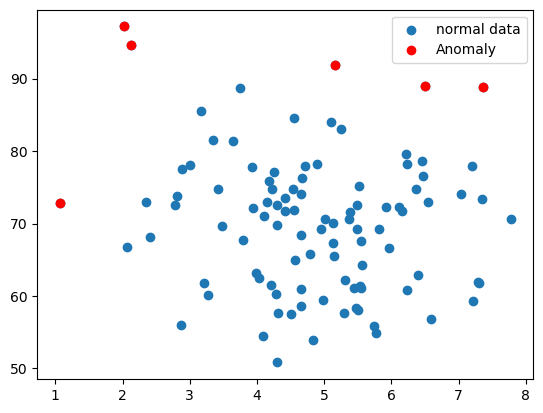

In [55]:
plt.scatter(X[:,0], X[:,1], label="normal data")
plt.scatter(X[anomalies][:,0],
            X[anomalies][:,1],
            color="red",
            label= "Anomaly")
plt.legend()
plt.show()